# Keras RNN forecast for VIX log returns

This notebook mirrors the data loading and lagged exogenous-variable processing from `arima.ipynb`, adds leakage-safe S&P 500 inputs, and trains a Keras GRU on walk-forward sequence windows.

In [1]:
import random

import numpy as np
import pandas as pd
try:
    import yahooquery as yq
except ImportError:
    yq = None

try:
    import yfinance as yf
except ImportError:
    yf = None

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.21.0


## Load and Prep Data

This follows the arima-presentation.ipynb data workflow: daily VIX, SPX, and GPR data with VIX log returns as the target. Reddit sentiment is intentionally excluded; set `MARKET_END = None` if you want to extend the baseline window to the latest available market data.


In [2]:
# Reddit sentiment is intentionally excluded from this model version.
# This keeps the modeling window driven by VIX, S&P 500, and GPR availability instead of Reddit history.


In [3]:
# https://www.matteoiacoviello.com/gpr.htm
# GPRD - Daily GPR (Index: 1985:2019=100)
# GPRD_ACT - Daily GPR Acts (Index: 1985:2019=100)
# GPRD_THREAT - Daily GPR Threats (Index: 1985:2019=100)
gpr_df = pd.read_stata("../data/gpr_daily.dta", columns=["date", "GPRD", "GPRD_ACT", "GPRD_THREAT"])
gpr_df["date"] = pd.to_datetime(gpr_df["date"])
gpr_df.head()


,date,GPRD,GPRD_ACT,GPRD_THREAT
0,1985-01-01,230.039429,275.197601,153.027985
1,1985-01-02,115.676971,146.772064,87.444572
2,1985-01-03,97.428459,158.937653,29.459934
3,1985-01-04,157.366638,156.882248,157.026352
4,1985-01-05,81.361313,92.698143,77.319405


In [4]:
MARKET_START = "1993-01-01"
MARKET_END = "2026-01-01"  # Set to None to pull the latest available market data.


def normalize_dates(values):
    dates = pd.to_datetime(values)
    if getattr(dates.dt, "tz", None) is not None:
        dates = dates.dt.tz_localize(None)
    return dates


def flatten_yahoo_columns(frame):
    out = frame.copy()
    if isinstance(out.columns, pd.MultiIndex):
        out.columns = [str(col[0]).lower().replace(" ", "") for col in out.columns]
    else:
        out.columns = [str(col).lower().replace(" ", "") for col in out.columns]
    return out


def effective_market_end(end=MARKET_END):
    if end is not None:
        return end
    return (pd.Timestamp.today().normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")


def load_yahoo_adjclose(symbol, yf_symbol=None, start=MARKET_START, end=MARKET_END):
    end = effective_market_end(end)
    if yq is not None:
        try:
            hist = yq.Ticker(symbol).history(interval="1d", start=start, end=end).reset_index()
            if not hist.empty and "adjclose" in hist.columns:
                hist["date"] = normalize_dates(hist["date"])
                return hist[["date", "adjclose"]].copy()
        except Exception as exc:
            print(f"yahooquery failed for {symbol}; trying yfinance fallback. Error: {exc}")

    if yf is None:
        raise ImportError("Install yahooquery or yfinance to download market history.")

    download_symbol = yf_symbol or symbol
    hist = yf.download(download_symbol, start=start, end=end, progress=False, auto_adjust=False).reset_index()
    hist = flatten_yahoo_columns(hist)
    if "adjclose" not in hist.columns:
        raise ValueError(f"No adjusted-close column returned for {download_symbol}.")
    hist["date"] = normalize_dates(hist["date"])
    return hist[["date", "adjclose"]].copy()


vix = load_yahoo_adjclose("^VIX").rename(columns={"adjclose": "vix_adjclose"})
spx = load_yahoo_adjclose("^SPX", yf_symbol="^GSPC").rename(columns={"adjclose": "spx_adjclose"})

vix.head()


,date,vix_adjclose
0,1993-01-04,13.36
1,1993-01-05,13.35
2,1993-01-06,13.37
3,1993-01-07,14.72
4,1993-01-08,13.77


In [5]:
def load_and_merge_data():
    merged = (
        vix
        .merge(gpr_df, on="date", how="left")
        .merge(spx, on="date", how="left")
        .dropna()
    )

    merged = merged.sort_values("date").reset_index(drop=True)
    merged["vix_log_return"] = np.log(merged["vix_adjclose"]).diff()
    merged["spx_log_return"] = np.log(merged["spx_adjclose"]).diff()
    return merged.dropna().reset_index(drop=True)


df = load_and_merge_data()
print(f"Rows available: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


Rows available: 8,306
Date range: 1993-01-05 to 2025-12-31


,date,vix_adjclose,GPRD,GPRD_ACT,GPRD_THREAT,spx_adjclose,vix_log_return,spx_log_return
0,1993-01-05,13.35,119.930664,82.456215,144.430908,434.339996,-0.000749,-0.002392
1,1993-01-06,13.37,84.319908,64.045990,106.841362,434.519989,0.001497,0.000414
2,1993-01-07,14.72,154.156281,71.479904,214.636658,430.730011,0.096194,-0.008760
3,1993-01-08,13.77,131.085571,105.958435,153.191666,429.049988,-0.066715,-0.003908
4,1993-01-11,12.86,149.133331,108.126747,180.376770,430.950012,-0.068371,0.004419


## Sequence Features

The RNN predicts one trading day at a time. Each target uses a lookback window ending on that target date, but all target-history and market features are shifted one row so the model only sees information available before the close being predicted.

In [6]:
TARGET_COL = "vix_log_return"
LAG_COLS = ["GPRD_THREAT", "GPRD_ACT", "GPRD", "spx_log_return"]
DEFAULT_ROLLING_WINDOWS = [21, 42, 365]
DEFAULT_ROLLING_SHIFTS = [1, 1, 1]
DEFAULT_ROLLING_STATS = "mean"
DEFAULT_ROLLING_TARGET_COLS = "vix_log_return"
AR_ORDER = 1
USE_AR_FEATURES = True


def add_lagged_exo_features(dataframe) -> pd.DataFrame:
    """Shift exogenous features back one trading period, as in arima-presentation.ipynb."""
    dataframe = dataframe.copy()
    for col in LAG_COLS:
        dataframe[f"{col.lower()}_shifted"] = dataframe[col].shift(1)
    return dataframe


def add_rolling_stats(
    frame: pd.DataFrame,
    windows: list[int],
    shifts: list[int],
    target_col: str | list[str] = "vix_log_return",
    stat: str | list[str] = "mean",
) -> pd.DataFrame:
    supported_stats = {"mean", "std", "min", "max"}

    if len(windows) != len(shifts):
        raise ValueError(f"`windows` and `shifts` must have the same length, got {len(windows)} and {len(shifts)}.")

    if isinstance(stat, str):
        if stat not in supported_stats:
            raise ValueError(f"Unsupported stat {stat!r}. Choose from {supported_stats}.")
        stats = [stat] * len(windows)
    else:
        if len(stat) != len(windows):
            raise ValueError(f"`stat` list must match length of `windows`, got {len(stat)} and {len(windows)}.")
        unsupported = set(stat) - supported_stats
        if unsupported:
            raise ValueError(f"Unsupported stats {unsupported}. Choose from {supported_stats}.")
        stats = list(stat)

    if isinstance(target_col, str):
        target_cols = [target_col] * len(windows)
    else:
        if len(target_col) != len(windows):
            raise ValueError(
                f"`target_col` list must match length of `windows`, got {len(target_col)} and {len(windows)}."
            )
        target_cols = list(target_col)

    missing = set(target_cols) - set(frame.columns)
    if missing:
        raise ValueError(f"Columns {missing} not found in frame.columns.")

    frame = frame.copy()
    for window, shift, s, col in zip(windows, shifts, stats, target_cols):
        rolled = frame[col].rolling(window=window, min_periods=window)
        series = getattr(rolled, s)()
        frame[f"{col}_{window}d_{s}_{shift}_shifted"] = series.shift(shift)

    return frame


def add_special_features(dataframe):
    dataframe = dataframe.copy()
    dataframe["days_since_last_trade"] = dataframe["date"].diff().dt.days.shift(1)
    return dataframe


def add_autoregressive_features(dataframe, p):
    dataframe = dataframe.copy()
    for i in range(p):
        dataframe[f"vix_log_return_shift_{i + 1}"] = dataframe["vix_log_return"].shift(i + 1)
    return dataframe


def build_modeling_frame(
    frame,
    windows=None,
    shifts=None,
    stats=None,
    target_cols=None,
    use_ar=USE_AR_FEATURES,
):
    full_df = frame.copy().reset_index(drop=True)
    if "_source_index" not in full_df.columns:
        full_df["_source_index"] = np.arange(len(full_df))

    full_df = add_lagged_exo_features(full_df)
    if use_ar:
        full_df = add_autoregressive_features(full_df, AR_ORDER)

    full_df = add_rolling_stats(
        full_df,
        windows=windows if windows is not None else DEFAULT_ROLLING_WINDOWS,
        shifts=shifts if shifts is not None else DEFAULT_ROLLING_SHIFTS,
        stat=stats if stats is not None else DEFAULT_ROLLING_STATS,
        target_col=target_cols if target_cols is not None else DEFAULT_ROLLING_TARGET_COLS,
    )
    full_df = add_special_features(full_df)
    full_df = full_df.dropna().reset_index(drop=True)

    feature_cols = [col for col in full_df.columns if col.endswith("_shifted")]
    if use_ar:
        feature_cols.extend([f"vix_log_return_shift_{i + 1}" for i in range(AR_ORDER)])

    return full_df, feature_cols


model_df, FEATURE_COLS = build_modeling_frame(df)

print(f"Rows available for RNN: {len(model_df):,}")
print(f"Date range: {model_df['date'].min().date()} to {model_df['date'].max().date()}")
print(f"Feature count: {len(FEATURE_COLS)}")
model_df[["date", TARGET_COL, *FEATURE_COLS]].head()


Rows available for RNN: 7,941
Date range: 1994-06-15 to 2025-12-31
Feature count: 8


,date,vix_log_return,gprd_threat_shifted,gprd_act_shifted,gprd_shifted,spx_log_return_shifted,vix_log_return_21d_mean_1_shifted,vix_log_return_42d_mean_1_shifted,vix_log_return_365d_mean_1_shifted,vix_log_return_shift_1
0,1994-06-15,-0.006920,146.418808,146.284454,132.062500,0.007097,-0.010757,-0.009128,-0.000387,-0.027213
1,1994-06-16,-0.026387,215.677032,110.817825,159.329315,-0.003814,-0.011510,-0.008220,-0.000404,-0.006920
2,1994-06-17,0.092714,161.396713,51.599552,122.927315,0.002862,-0.010812,-0.008420,-0.000480,-0.026387
3,1994-06-20,0.125784,177.530960,33.256508,120.093086,-0.007562,-0.000919,-0.007992,-0.000490,0.092714
4,1994-06-21,0.051651,211.360443,81.741867,163.988495,-0.006499,0.005912,-0.004593,0.000038,0.125784


## Keras Dataset and Model

In [7]:
LOOKBACK_DAYS = 20
BATCH_SIZE = 32
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.0
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 75
PATIENCE = 10

N_SPLITS = 4
TEST_SIZE = 242
VALIDATION_SIZE = 242

MODEL_NAME = "keras_gru"
MODEL_LABEL = "Keras GRU RNN"


In [8]:
def eligible_target_indices(indices, lookback_days):
    return [int(idx) for idx in indices if int(idx) >= lookback_days - 1]


def split_train_validation(train_target_indices, validation_size=VALIDATION_SIZE):
    train_target_indices = list(train_target_indices)
    if len(train_target_indices) <= validation_size + 1:
        validation_size = max(1, len(train_target_indices) // 5)
    return train_target_indices[:-validation_size], train_target_indices[-validation_size:]


def build_sequence_arrays(frame, target_indices, feature_cols, target_col, feature_scaler, target_scaler, lookback_days):
    raw_features = frame[feature_cols].astype(np.float32)
    raw_targets = frame[[target_col]].astype(np.float32)
    features = feature_scaler.transform(raw_features).astype(np.float32)
    targets_scaled = target_scaler.transform(raw_targets).reshape(-1).astype(np.float32)
    targets_raw = raw_targets.to_numpy(dtype=np.float32).reshape(-1)

    x, y, y_raw, kept_indices = [], [], [], []
    for target_idx in target_indices:
        target_idx = int(target_idx)
        start_idx = target_idx - lookback_days + 1
        if start_idx < 0:
            continue
        x.append(features[start_idx:target_idx + 1])
        y.append(targets_scaled[target_idx])
        y_raw.append(targets_raw[target_idx])
        kept_indices.append(target_idx)

    return (
        np.asarray(x, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(y_raw, dtype=np.float32),
        np.asarray(kept_indices, dtype=int),
    )


def make_arrays_for_fold(train_idx, test_idx):
    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)
    full_idx = np.concatenate([train_idx, test_idx])

    fold_source_df = df.iloc[full_idx].copy()
    fold_source_df["_source_index"] = full_idx
    fold_model_df, feature_cols = build_modeling_frame(fold_source_df)

    train_target_indices = np.flatnonzero(fold_model_df["_source_index"].isin(train_idx)).astype(int)
    test_target_indices = np.flatnonzero(fold_model_df["_source_index"].isin(test_idx)).astype(int)
    train_target_indices = eligible_target_indices(train_target_indices, LOOKBACK_DAYS)
    test_target_indices = eligible_target_indices(test_target_indices, LOOKBACK_DAYS)
    fit_target_indices, val_target_indices = split_train_validation(train_target_indices)

    if not fit_target_indices or not val_target_indices or not test_target_indices:
        raise ValueError("Fold does not have enough rows after feature engineering for train/validation/test sequences.")

    scaler_fit_idx = np.arange(max(fit_target_indices) + 1)
    feature_scaler = StandardScaler().fit(fold_model_df.iloc[scaler_fit_idx][feature_cols])
    target_scaler = StandardScaler().fit(fold_model_df.iloc[fit_target_indices][[TARGET_COL]])

    train_arrays = build_sequence_arrays(
        fold_model_df, fit_target_indices, feature_cols, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    val_arrays = build_sequence_arrays(
        fold_model_df, val_target_indices, feature_cols, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    test_arrays = build_sequence_arrays(
        fold_model_df, test_target_indices, feature_cols, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    fold_indices = {
        "fit_target_indices": np.asarray(fit_target_indices, dtype=int),
        "val_target_indices": np.asarray(val_target_indices, dtype=int),
        "test_target_indices": np.asarray(test_target_indices, dtype=int),
        "scaler_fit_indices": np.asarray(scaler_fit_idx, dtype=int),
    }
    return train_arrays, val_arrays, test_arrays, target_scaler, fold_indices, fold_model_df, feature_cols


def build_keras_rnn(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for layer_idx in range(NUM_LAYERS):
        return_sequences = layer_idx < NUM_LAYERS - 1
        x = layers.GRU(
            HIDDEN_SIZE,
            return_sequences=return_sequences,
            dropout=DROPOUT,
            recurrent_dropout=0.0,
        )(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dense(HIDDEN_SIZE // 2, activation="gelu")(x)
    if DROPOUT > 0:
        x = layers.Dropout(DROPOUT)(x)
    outputs = layers.Dense(1)(x)

    try:
        optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    except AttributeError:
        optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=optimizer, loss="mse")
    return model


def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=np.float64)
    predicted = np.asarray(predicted, dtype=np.float64)
    actual_rise = (actual > 0).astype(int)
    predicted_rise = (predicted > 0).astype(int)
    mse = mean_squared_error(actual, predicted)
    metrics = {
        "mse": float(mse),
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
        "swing_accuracy": float(accuracy_score(actual_rise, predicted_rise)),
        "directional_accuracy": float(accuracy_score(actual_rise, predicted_rise)),
    }
    if len(np.unique(actual_rise)) > 1:
        metrics["swing_balanced_accuracy"] = float(balanced_accuracy_score(actual_rise, predicted_rise))
    else:
        metrics["swing_balanced_accuracy"] = np.nan
    return metrics


def evaluate_predictions(frame, pred_scaled, y_raw, target_indices, target_scaler):
    pred_raw = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)
    source_indices = frame.iloc[target_indices]["_source_index"].to_numpy(dtype=int)
    out = pd.DataFrame({
        "target_index": source_indices,
        "fold_row_index": target_indices,
        "date": frame.iloc[target_indices]["date"].to_numpy(),
        "actual": y_raw,
        "predicted": pred_raw,
    })
    metrics = regression_metrics(out["actual"], out["predicted"])
    return metrics, out


## Walk-Forward Evaluation

This uses the same four-fold, 242-trading-day `TimeSeriesSplit` setup as `arima-presentation.ipynb`. The scaler is fit on each fold's training rows only; test sequences may use prior observed returns through yesterday, matching a one-day-ahead walk-forward forecast.



Epoch 1/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 1.0557 - val_loss: 1.5127
Epoch 2/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.0045 - val_loss: 1.4977
Epoch 3/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9874 - val_loss: 1.4947
Epoch 4/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.9774 - val_loss: 1.4941
Epoch 5/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.9706 - val_loss: 1.4972
Epoch 6/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.9650 - val_loss: 1.5047
Epoch 7/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.9600 - val_loss: 1.5128
Epoch 8/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.9552 - val_loss: 1.5208
Epoch 9/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.9502 - val_loss: 1.5285
Epoch 10/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.9447 - val_loss: 1.5367
Epoch 11/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.9382 - val_loss: 1.5465
Epoch 12/75
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms

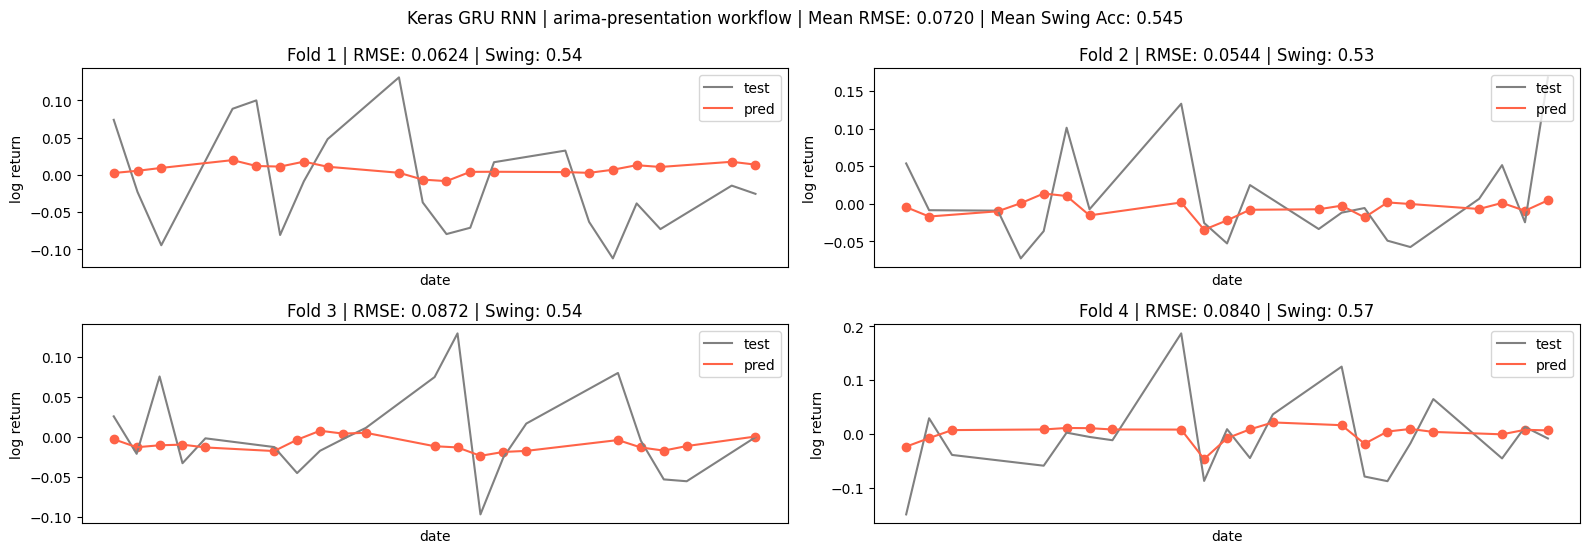

mse: 0.005377437636877451
rmse: 0.07199531546336577
accuracy: 0.5454545454545455
balanced_accuracy: 0.5474647001640801


,model,mean_mse,mean_rmse,mean_mae,mean_r2,mean_swing_accuracy,mean_swing_balanced_accuracy
0,keras_gru,0.005377,0.071995,0.050304,-0.000203,0.545455,0.547465
3,zero_return,0.005392,0.072054,0.050702,-0.000483,0.568182,0.500000
2,train_mean,0.005392,0.072055,0.050711,-0.000528,0.458678,0.500000
1,previous_vix_return,0.011322,0.104432,0.074572,-1.104032,0.473140,0.462750


,fold,model,epochs,mse,rmse,mae,r2,swing_accuracy,directional_accuracy,swing_balanced_accuracy
0,1,keras_gru,14.0,0.003892,0.062385,0.047798,-0.023196,0.541322,0.541322,0.559052
1,1,zero_return,NaN,0.003806,0.061694,0.047499,-0.000661,0.590909,0.590909,0.500000
2,1,train_mean,NaN,0.003806,0.061696,0.047514,-0.000735,0.409091,0.409091,0.500000
3,1,previous_vix_return,NaN,0.008104,0.090023,0.067457,-1.130637,0.471074,0.471074,0.452991
4,2,keras_gru,13.0,0.002961,0.054411,0.041712,0.004844,0.528926,0.528926,0.539262
5,2,zero_return,NaN,0.002978,0.054568,0.041977,-0.000883,0.561983,0.561983,0.500000
6,2,train_mean,NaN,0.002978,0.054571,0.041991,-0.001007,0.438017,0.438017,0.500000
7,2,previous_vix_return,NaN,0.006230,0.078933,0.060325,-1.094256,0.508264,0.508264,0.501110
8,3,keras_gru,11.0,0.007603,0.087194,0.054135,-0.012199,0.541322,0.541322,0.532603
9,3,zero_return,NaN,0.007513,0.086678,0.054307,-0.000269,0.566116,0.566116,0.500000


In [9]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
fold_splits = list(tscv.split(df))
n_folds = len(fold_splits)
plot_cols = min(2, max(1, n_folds))
plot_rows = int(np.ceil(n_folds / plot_cols))

fold_metrics = []
fold_predictions = []
fold_histories = []
fold_target_summaries = []
fig, axes = plt.subplots(
    nrows=plot_rows,
    ncols=plot_cols,
    figsize=(8 * plot_cols, 2.8 * plot_rows),
    squeeze=False,
)
axes = axes.ravel()

for fold, (train_idx, test_idx) in enumerate(fold_splits):
    (
        train_arrays,
        val_arrays,
        test_arrays,
        target_scaler,
        fold_indices,
        fold_model_df,
        fold_feature_cols,
    ) = make_arrays_for_fold(train_idx, test_idx)
    x_train, y_train, _, _ = train_arrays
    x_val, y_val, _, _ = val_arrays
    x_test, _, y_test_raw, test_target_indices = test_arrays

    for split_name, indices in [
        ("train", fold_indices["fit_target_indices"]),
        ("validation", fold_indices["val_target_indices"]),
        ("test", fold_indices["test_target_indices"]),
    ]:
        values = fold_model_df.iloc[indices][TARGET_COL].to_numpy(dtype=np.float64)
        fold_target_summaries.append({
            "fold": fold + 1,
            "split": split_name,
            "rows": len(values),
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)),
            "min": float(np.min(values)),
            "max": float(np.max(values)),
        })

    keras.backend.clear_session()
    tf.random.set_seed(RANDOM_SEED + fold)
    model = build_keras_rnn(input_shape=(LOOKBACK_DAYS, len(fold_feature_cols)))

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            min_delta=1e-5,
            restore_best_weights=True,
        )
    ]

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
    )
    fold_history = pd.DataFrame({
        "fold": fold + 1,
        "epoch": np.arange(1, len(history.history["loss"]) + 1),
        "train_loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
    })
    fold_histories.append(fold_history)

    pred_scaled = model.predict(x_test, verbose=0).reshape(-1)
    test_metrics, preds = evaluate_predictions(fold_model_df, pred_scaled, y_test_raw, test_target_indices, target_scaler)
    preds["fold"] = fold + 1
    fold_predictions.append(preds)
    fold_metrics.append({"fold": fold + 1, "model": "keras_gru", "epochs": len(history.history["loss"]), **test_metrics})

    train_target_values = fold_model_df.iloc[fold_indices["fit_target_indices"]][TARGET_COL].to_numpy(dtype=np.float64)
    baseline_predictions = {
        "zero_return": np.zeros_like(y_test_raw, dtype=np.float64),
        "train_mean": np.full_like(y_test_raw, train_target_values.mean(), dtype=np.float64),
        "previous_vix_return": fold_model_df[TARGET_COL].shift(1).iloc[test_target_indices].to_numpy(dtype=np.float64),
    }
    for baseline_name, baseline_pred in baseline_predictions.items():
        fold_metrics.append({
            "fold": fold + 1,
            "model": baseline_name,
            "epochs": np.nan,
            **regression_metrics(y_test_raw, baseline_pred),
        })

    ax = axes[fold]
    display_n = min(20, len(preds))
    ax.plot(preds["date"].iloc[:display_n], preds["actual"].iloc[:display_n], color="grey", label="test")
    ax.plot(preds["date"].iloc[:display_n], preds["predicted"].iloc[:display_n], color="tomato", label="pred")
    ax.scatter(preds["date"].iloc[:display_n], preds["predicted"].iloc[:display_n], marker="o", color="tomato")
    ax.set_title(
        f"Fold {fold + 1} | RMSE: {test_metrics['rmse']:.4f} | Swing: {test_metrics['swing_accuracy']:.2f}"
    )
    ax.set_xlabel("date")
    ax.set_ylabel("log return")
    ax.set_xticks([])
    ax.legend(loc="upper right")

for ax in axes[n_folds:]:
    ax.set_visible(False)

metrics_df = pd.DataFrame(fold_metrics)
predictions_df = pd.concat(fold_predictions, ignore_index=True)
history_df = pd.concat(fold_histories, ignore_index=True)
target_summary_df = pd.DataFrame(fold_target_summaries)

mean_gru_rmse = metrics_df.loc[metrics_df["model"].eq("keras_gru"), "rmse"].mean()
mean_gru_swing_accuracy = metrics_df.loc[metrics_df["model"].eq("keras_gru"), "swing_accuracy"].mean()
mean_gru_balanced_swing_accuracy = metrics_df.loc[metrics_df["model"].eq("keras_gru"), "swing_balanced_accuracy"].mean()

plt.suptitle(
    "Keras GRU RNN | arima-presentation workflow | "
    f"Mean RMSE: {mean_gru_rmse:.4f} | "
    f"Mean Swing Acc: {mean_gru_swing_accuracy:.3f}"
)
plt.tight_layout()
plt.show()

model_summary = (
    metrics_df.groupby("model", as_index=False)
    .agg(
        mean_mse=("mse", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        mean_r2=("r2", "mean"),
        mean_swing_accuracy=("swing_accuracy", "mean"),
        mean_swing_balanced_accuracy=("swing_balanced_accuracy", "mean"),
    )
    .sort_values("mean_rmse")
)

print(f"mse: {metrics_df.loc[metrics_df['model'].eq('keras_gru'), 'mse'].mean()}")
print(f"rmse: {mean_gru_rmse}")
print(f"accuracy: {mean_gru_swing_accuracy}")
print(f"balanced_accuracy: {mean_gru_balanced_swing_accuracy}")
display(model_summary)
metrics_df


## Fold Test Prediction Plots

This repeats the four-fold test prediction view used in `arima-presentation.ipynb`, using the held-out predictions saved by the walk-forward evaluation cell.


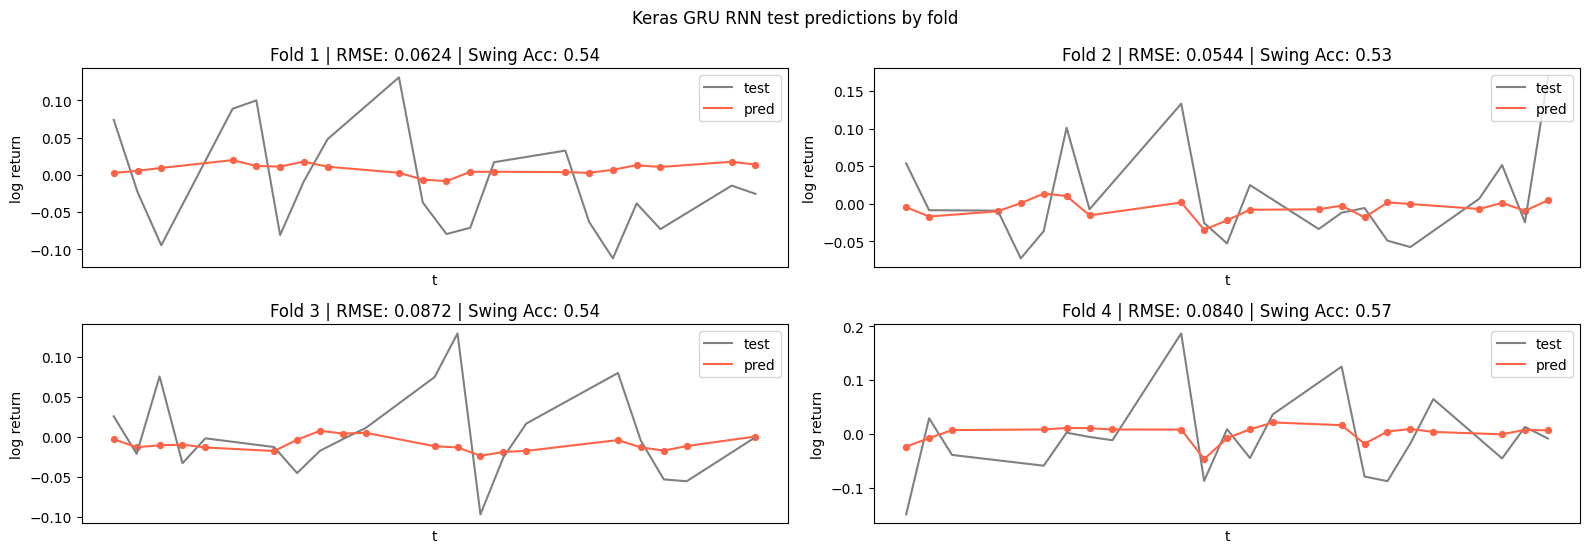

In [10]:
if "predictions_df" not in globals() or "metrics_df" not in globals():
    raise RuntimeError("Run the walk-forward evaluation cell first so predictions_df and metrics_df are available.")

PLOT_FIRST_N_TEST_DAYS = 20
fold_ids = sorted(predictions_df["fold"].unique())
plot_cols = min(2, max(1, len(fold_ids)))
plot_rows = int(np.ceil(len(fold_ids) / plot_cols))

fig, axes = plt.subplots(
    nrows=plot_rows,
    ncols=plot_cols,
    figsize=(8 * plot_cols, 2.8 * plot_rows),
    squeeze=False,
)
axes = axes.ravel()

for ax, fold_id in zip(axes, fold_ids):
    fold_preds = predictions_df[predictions_df["fold"].eq(fold_id)].sort_values("date")
    if PLOT_FIRST_N_TEST_DAYS is not None:
        fold_preds = fold_preds.head(PLOT_FIRST_N_TEST_DAYS)

    fold_metrics_row = metrics_df[
        metrics_df["fold"].eq(fold_id) & metrics_df["model"].eq(MODEL_NAME)
    ].iloc[0]

    ax.plot(fold_preds["date"], fold_preds["actual"], color="grey", label="test")
    ax.plot(fold_preds["date"], fold_preds["predicted"], color="tomato", label="pred")
    ax.scatter(fold_preds["date"], fold_preds["predicted"], marker="o", color="tomato", s=18)
    ax.set_title(
        f"Fold {fold_id} | RMSE: {fold_metrics_row['rmse']:.4f} | "
        f"Swing Acc: {fold_metrics_row['swing_accuracy']:.2f}"
    )
    ax.set_xlabel("t")
    ax.set_ylabel("log return")
    ax.set_xticks([])
    ax.legend(loc="upper right")

for ax in axes[len(fold_ids):]:
    ax.set_visible(False)

plt.suptitle(f"{MODEL_LABEL} test predictions by fold")
plt.tight_layout()
plt.show()


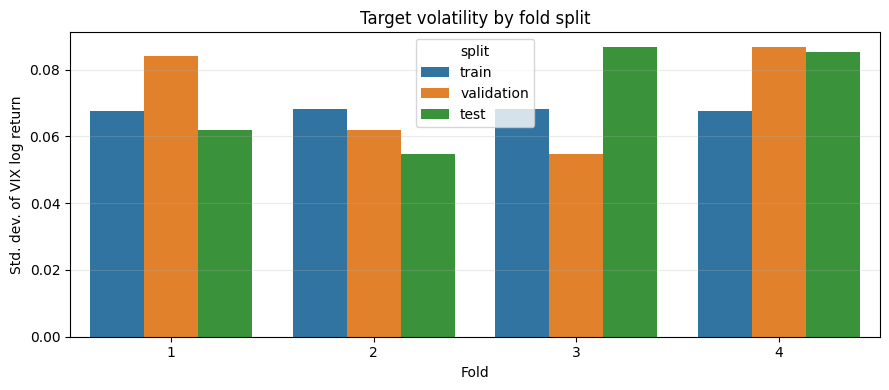

,fold,split,rows,mean,std,min,max
0,1,train,6712,0.000087,0.067713,-0.350589,0.768245
1,1,validation,242,0.000750,0.084004,-0.220352,0.432020
2,1,test,242,-0.001585,0.061801,-0.140343,0.218193
3,2,train,6954,0.000110,0.068338,-0.350589,0.768245
4,2,validation,242,-0.001585,0.061801,-0.140343,0.218193
5,2,test,242,-0.001621,0.054657,-0.155894,0.168181
6,3,train,7196,0.000053,0.068125,-0.350589,0.768245
7,3,validation,242,-0.001621,0.054657,-0.155894,0.168181
8,3,test,242,0.001423,0.086846,-0.330681,0.554110
9,4,train,7438,-0.000001,0.067727,-0.350589,0.768245


In [11]:
if "target_summary_df" not in globals():
    raise RuntimeError("Run the walk-forward evaluation cell first so target_summary_df is available.")

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=target_summary_df, x="fold", y="std", hue="split", ax=ax)
ax.set_title("Target volatility by fold split")
ax.set_xlabel("Fold")
ax.set_ylabel("Std. dev. of VIX log return")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

target_summary_df


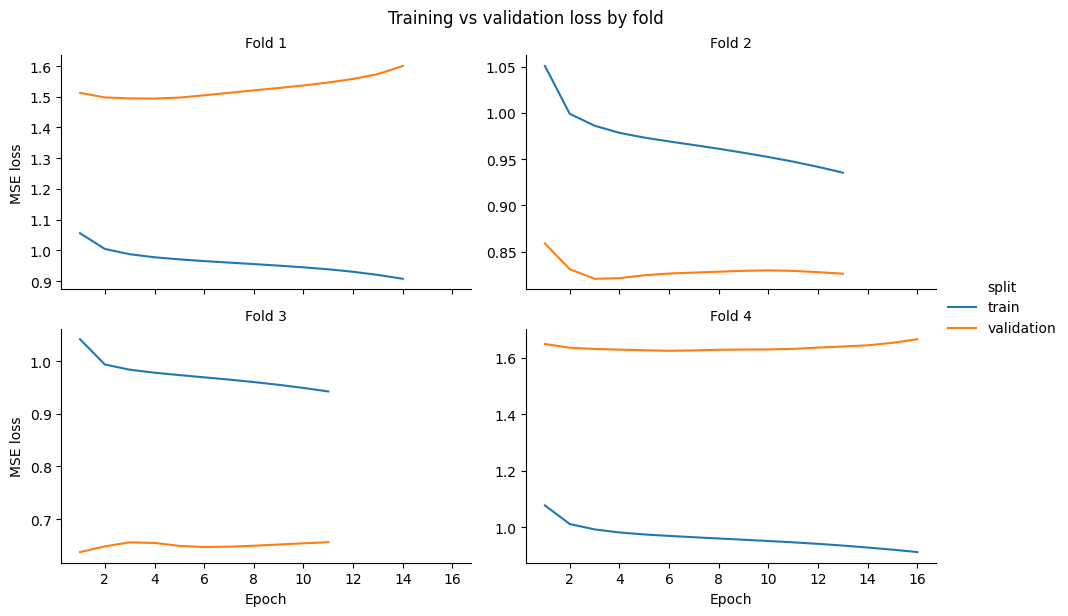

,fold,epoch,train_loss,val_loss
0,1,14,0.907353,1.600167
1,2,13,0.935279,0.826102
2,3,11,0.942271,0.656171
3,4,16,0.913019,1.664711


In [12]:
if "history_df" not in globals():
    raise RuntimeError("Run the walk-forward evaluation cell first so history_df is available.")

loss_long = history_df.melt(
    id_vars=["fold", "epoch"],
    value_vars=["train_loss", "val_loss"],
    var_name="split",
    value_name="loss",
)
loss_long["split"] = loss_long["split"].map({"train_loss": "train", "val_loss": "validation"})
loss_col_wrap = min(2, max(1, history_df["fold"].nunique()))

g = sns.relplot(
    data=loss_long,
    x="epoch",
    y="loss",
    hue="split",
    col="fold",
    col_wrap=loss_col_wrap,
    kind="line",
    height=3,
    aspect=1.6,
    facet_kws={"sharey": False},
)
g.set_titles("Fold {col_name}")
g.set_axis_labels("Epoch", "MSE loss")
g.fig.suptitle("Training vs validation loss by fold", y=1.02)
plt.show()

history_df.groupby("fold").tail(1).reset_index(drop=True)


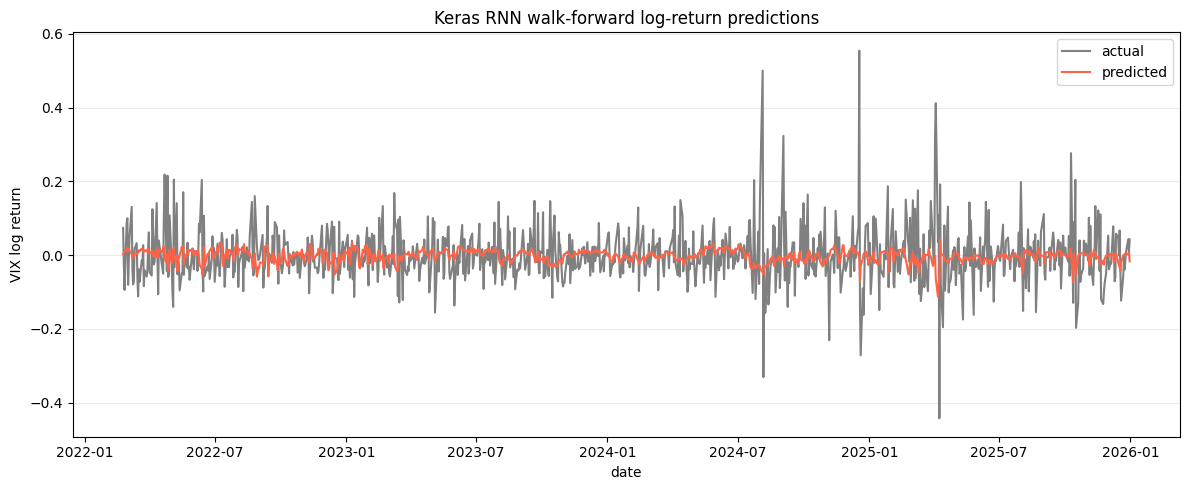

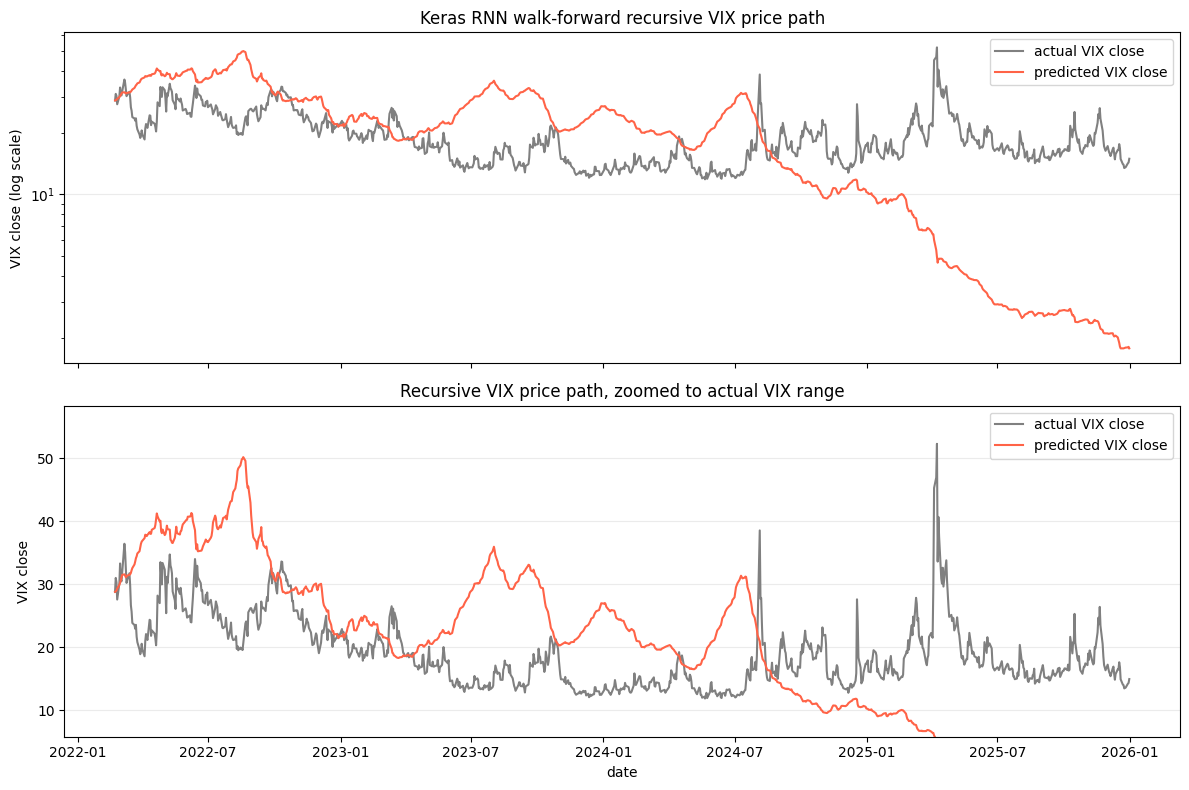

Keras GRU mean log-return RMSE: 0.0720
Keras GRU mean log-return MAE: 0.0503
Keras GRU recursive VIX price RMSE: 11.9721
Keras GRU recursive VIX price MAE: 10.0269
Keras GRU one-day anchored VIX price RMSE: 1.7552
Keras GRU one-day anchored VIX price MAE: 1.0324
Max actual price reconstruction error from one-day log returns: 0.00000365
Max actual price reconstruction error from cumulative log returns: 0.00000181


,date,actual_vix_price,predicted_vix_price,predicted_vix_price_one_day,actual_simple_return,predicted_simple_return,fold
0,2022-02-23,31.02,28.884520,28.884520,0.076710,0.002587,1
1,2022-02-24,30.32,29.045078,31.192429,-0.022566,0.005559,1
2,2022-02-25,27.59,29.318977,30.605919,-0.090040,0.009430,1
3,2022-02-28,30.15,29.906886,28.143237,0.092787,0.020052,1
4,2022-03-01,33.32,30.266852,30.512891,0.105141,0.012036,1


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=predictions_df, x="date", y="actual", label="actual", color="grey", ax=ax)
sns.lineplot(data=predictions_df, x="date", y="predicted", label="predicted", color="tomato", ax=ax)
ax.set_title("Keras RNN walk-forward log-return predictions")
ax.set_xlabel("date")
ax.set_ylabel("VIX log return")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

required_price_cols = {"vix_adjclose"}
missing_price_cols = sorted(required_price_cols.difference(df.columns))
if missing_price_cols:
    raise ValueError(f"df is missing price columns needed for price reconstruction: {missing_price_cols}")

price_predictions_df = (
    predictions_df.copy()
    .sort_values(["target_index", "fold"])
    .drop_duplicates(subset=["target_index"], keep="last")
    .sort_values("target_index")
    .reset_index(drop=True)
)

target_positions = price_predictions_df["target_index"].to_numpy(dtype=int)
previous_target_positions = target_positions - 1
if len(target_positions) == 0:
    raise ValueError("predictions_df is empty; run the walk-forward evaluation cell first.")
if np.any(previous_target_positions < 0):
    raise ValueError("Cannot build price predictions without a prior VIX close for every target row.")

price_predictions_df["date"] = df.iloc[target_positions]["date"].to_numpy()
price_predictions_df["actual_vix_price"] = df.iloc[target_positions]["vix_adjclose"].to_numpy(dtype=np.float64)
price_predictions_df["previous_actual_vix_price"] = df.iloc[previous_target_positions]["vix_adjclose"].to_numpy(dtype=np.float64)
price_predictions_df["actual_simple_return"] = np.expm1(price_predictions_df["actual"])
price_predictions_df["predicted_simple_return"] = np.expm1(price_predictions_df["predicted"])
price_predictions_df["actual_vix_price_from_return"] = (
    price_predictions_df["previous_actual_vix_price"] * np.exp(price_predictions_df["actual"])
)
price_predictions_df["predicted_vix_price_one_day"] = (
    price_predictions_df["previous_actual_vix_price"] * np.exp(price_predictions_df["predicted"])
)

anchor_index = int(previous_target_positions[0])
anchor_row = df.iloc[anchor_index]
anchor_date = anchor_row["date"]
anchor_price = float(anchor_row["vix_adjclose"])

actual_path_prices = []
predicted_path_prices = []
previous_actual_path_price = anchor_price
previous_predicted_path_price = anchor_price
for actual_log_return, predicted_log_return in zip(
    price_predictions_df["actual"].to_numpy(dtype=np.float64),
    price_predictions_df["predicted"].to_numpy(dtype=np.float64),
):
    previous_actual_path_price = previous_actual_path_price * np.exp(actual_log_return)
    previous_predicted_path_price = previous_predicted_path_price * np.exp(predicted_log_return)
    actual_path_prices.append(previous_actual_path_price)
    predicted_path_prices.append(previous_predicted_path_price)

price_predictions_df["actual_vix_price_from_path"] = actual_path_prices
price_predictions_df["predicted_vix_price"] = predicted_path_prices

non_consecutive_targets = price_predictions_df["target_index"].diff().dropna().ne(1)
if non_consecutive_targets.any():
    print(
        "Warning: predicted target rows are not consecutive; "
        "the recursive price path compounds across available predicted rows."
    )

price_plot_df = pd.concat(
    [
        pd.DataFrame(
            {
                "date": [anchor_date],
                "actual_vix_price": [anchor_price],
                "predicted_vix_price": [anchor_price],
            }
        ),
        price_predictions_df[["date", "actual_vix_price", "predicted_vix_price"]],
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
for ax in axes:
    ax.plot(price_plot_df["date"], price_plot_df["actual_vix_price"], label="actual VIX close", color="grey")
    ax.plot(price_plot_df["date"], price_plot_df["predicted_vix_price"], label="predicted VIX close", color="tomato")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()

axes[0].set_yscale("log")
axes[0].set_title("Keras RNN walk-forward recursive VIX price path")
axes[0].set_ylabel("VIX close (log scale)")

actual_min = price_plot_df["actual_vix_price"].min()
actual_max = price_plot_df["actual_vix_price"].max()
actual_padding = max((actual_max - actual_min) * 0.15, 1.0)
axes[1].set_ylim(max(0, actual_min - actual_padding), actual_max + actual_padding)
axes[1].set_title("Recursive VIX price path, zoomed to actual VIX range")
axes[1].set_xlabel("date")
axes[1].set_ylabel("VIX close")
plt.tight_layout()
plt.show()

keras_rows = metrics_df[metrics_df["model"].eq("keras_gru")]
recursive_price_metrics = regression_metrics(
    price_predictions_df["actual_vix_price"],
    price_predictions_df["predicted_vix_price"],
)
one_day_price_metrics = regression_metrics(
    price_predictions_df["actual_vix_price"],
    price_predictions_df["predicted_vix_price_one_day"],
)
one_day_reconstruction_error = (
    price_predictions_df["actual_vix_price"] - price_predictions_df["actual_vix_price_from_return"]
).abs().max()
path_reconstruction_error = (
    price_predictions_df["actual_vix_price"] - price_predictions_df["actual_vix_price_from_path"]
).abs().max()
print(f"Keras GRU mean log-return RMSE: {keras_rows['rmse'].mean():.4f}")
print(f"Keras GRU mean log-return MAE: {keras_rows['mae'].mean():.4f}")
print(f"Keras GRU recursive VIX price RMSE: {recursive_price_metrics['rmse']:.4f}")
print(f"Keras GRU recursive VIX price MAE: {recursive_price_metrics['mae']:.4f}")
print(f"Keras GRU one-day anchored VIX price RMSE: {one_day_price_metrics['rmse']:.4f}")
print(f"Keras GRU one-day anchored VIX price MAE: {one_day_price_metrics['mae']:.4f}")
print(f"Max actual price reconstruction error from one-day log returns: {one_day_reconstruction_error:.8f}")
print(f"Max actual price reconstruction error from cumulative log returns: {path_reconstruction_error:.8f}")
price_predictions_df[
    [
        "date",
        "actual_vix_price",
        "predicted_vix_price",
        "predicted_vix_price_one_day",
        "actual_simple_return",
        "predicted_simple_return",
        "fold",
    ]
].head()


# Backtesting

This mirrors the strategy in `arima-presentation.ipynb`: train a final neural model on pre-2023 data, tune VIX log-return thresholds on 2023 SPY data, then apply those thresholds to 2024 SPY data.


In [14]:
from backtesting import Backtest, Strategy


class VixPredStrategy(Strategy):
    vix_rise_threshold = 0.015   # above this -> expect SPY weakness, close any long
    vix_fall_threshold = -0.015  # below this -> expect SPY strength, enter long

    def init(self):
        self.vix_pred = self.I(func=lambda: self.data.PredVixLogReturn, name="PredVixLogReturn")

    def next(self):
        pred = self.vix_pred[-1]

        if not self.position:
            if pred < self.vix_fall_threshold:
                self.buy()
        else:
            if pred > self.vix_rise_threshold:
                self.position.close()


def fetch_spx(start, end):
    if yq is not None:
        try:
            hist = yq.Ticker("SPY").history(start=start, end=end).reset_index()
            if not hist.empty:
                hist = flatten_yahoo_columns(hist)
                hist["date"] = normalize_dates(hist["date"])
                hist = hist.rename(columns={
                    "open": "Open",
                    "high": "High",
                    "low": "Low",
                    "close": "Close",
                    "volume": "Volume",
                })
                return hist.set_index("date")[["Open", "High", "Low", "Close", "Volume"]].dropna()
        except Exception as exc:
            print(f"yahooquery failed for SPY OHLCV; trying yfinance fallback. Error: {exc}")

    if yf is None:
        raise ImportError("Install yahooquery or yfinance to download SPY OHLCV data.")

    hist = yf.download("SPY", start=start, end=end, progress=False, auto_adjust=False).reset_index()
    hist = flatten_yahoo_columns(hist)
    hist["date"] = normalize_dates(hist["date"])
    hist = hist.rename(columns={
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume",
    })
    return hist.set_index("date")[["Open", "High", "Low", "Close", "Volume"]].dropna()


def attach_preds(spx_df, prediction_frame):
    dates = normalize_dates(pd.Series(prediction_frame["date"].values))
    pred_series = pd.Series(prediction_frame["predicted"].values, index=dates).shift(1)
    spx = spx_df[spx_df.index.isin(pred_series.index)].copy()
    spx["PredVixLogReturn"] = pred_series.reindex(spx.index)
    return spx.dropna()


def plot_backtest_equity(test_results, validation_results, model_label):
    fig, ax = plt.subplots(figsize=(10, 4))
    test_results["_equity_curve"]["Equity"].plot(ax=ax, label="2023 threshold-tuning period", color="steelblue")
    validation_results["_equity_curve"]["Equity"].plot(ax=ax, label="2024 validation period", color="tomato")
    ax.set_title(f"{model_label} VIX-threshold strategy equity")
    ax.set_xlabel("date")
    ax.set_ylabel("account value")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


spx_test_df = fetch_spx("2023-01-01", "2024-01-01")
spx_val_df = fetch_spx("2024-01-01", "2025-01-01")


c:\Users\jfigg\.conda\envs\keras_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\jfigg\.conda\envs\keras_env\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [15]:
FINAL_TRAIN_END = "2023-01-01"
FINAL_TEST_END = "2024-01-01"
FINAL_VAL_END = "2025-01-01"


def make_final_backtest_arrays():
    final_source_df = df.copy()
    final_source_df["_source_index"] = np.arange(len(df))
    final_model_df, final_feature_cols = build_modeling_frame(final_source_df)
    final_dates = pd.to_datetime(final_model_df["date"])

    train_target_indices = np.flatnonzero(final_dates.lt(FINAL_TRAIN_END)).astype(int)
    test_target_indices = np.flatnonzero(
        final_dates.ge(FINAL_TRAIN_END) & final_dates.lt(FINAL_TEST_END)
    ).astype(int)
    val_target_indices = np.flatnonzero(
        final_dates.ge(FINAL_TEST_END) & final_dates.lt(FINAL_VAL_END)
    ).astype(int)

    train_target_indices = eligible_target_indices(train_target_indices, LOOKBACK_DAYS)
    test_target_indices = eligible_target_indices(test_target_indices, LOOKBACK_DAYS)
    val_target_indices = eligible_target_indices(val_target_indices, LOOKBACK_DAYS)
    fit_target_indices, early_stop_target_indices = split_train_validation(train_target_indices)

    if not fit_target_indices or not early_stop_target_indices or not test_target_indices or not val_target_indices:
        raise ValueError("Not enough rows after feature engineering for the final train/test/validation backtest split.")

    scaler_fit_idx = np.arange(max(fit_target_indices) + 1)
    feature_scaler = StandardScaler().fit(final_model_df.iloc[scaler_fit_idx][final_feature_cols])
    target_scaler = StandardScaler().fit(final_model_df.iloc[fit_target_indices][[TARGET_COL]])

    train_arrays = build_sequence_arrays(
        final_model_df,
        fit_target_indices,
        final_feature_cols,
        TARGET_COL,
        feature_scaler,
        target_scaler,
        LOOKBACK_DAYS,
    )
    early_stop_arrays = build_sequence_arrays(
        final_model_df,
        early_stop_target_indices,
        final_feature_cols,
        TARGET_COL,
        feature_scaler,
        target_scaler,
        LOOKBACK_DAYS,
    )
    test_arrays = build_sequence_arrays(
        final_model_df,
        test_target_indices,
        final_feature_cols,
        TARGET_COL,
        feature_scaler,
        target_scaler,
        LOOKBACK_DAYS,
    )
    val_arrays = build_sequence_arrays(
        final_model_df,
        val_target_indices,
        final_feature_cols,
        TARGET_COL,
        feature_scaler,
        target_scaler,
        LOOKBACK_DAYS,
    )

    split_indices = {
        "fit": np.asarray(fit_target_indices, dtype=int),
        "early_stop": np.asarray(early_stop_target_indices, dtype=int),
        "test": np.asarray(test_target_indices, dtype=int),
        "validation": np.asarray(val_target_indices, dtype=int),
    }
    return final_model_df, final_feature_cols, train_arrays, early_stop_arrays, test_arrays, val_arrays, target_scaler, split_indices


(
    final_model_df,
    final_feature_cols,
    final_train_arrays,
    final_early_stop_arrays,
    final_test_arrays,
    final_val_arrays,
    final_target_scaler,
    final_split_indices,
) = make_final_backtest_arrays()

x_final_train, y_final_train, _, _ = final_train_arrays
x_final_early_stop, y_final_early_stop, _, _ = final_early_stop_arrays
x_final_test, _, y_final_test_raw, final_test_target_indices = final_test_arrays
x_final_val, _, y_final_val_raw, final_val_target_indices = final_val_arrays

keras.backend.clear_session()
tf.random.set_seed(RANDOM_SEED + 50_000)
final_model = build_keras_rnn(input_shape=(LOOKBACK_DAYS, len(final_feature_cols)))

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        min_delta=1e-5,
        restore_best_weights=True,
    )
]

final_history = final_model.fit(
    x_final_train,
    y_final_train,
    validation_data=(x_final_early_stop, y_final_early_stop),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    shuffle=True,
)

final_test_pred_scaled = final_model.predict(x_final_test, verbose=0).reshape(-1)
final_val_pred_scaled = final_model.predict(x_final_val, verbose=0).reshape(-1)

final_test_metrics, final_test_predictions_df = evaluate_predictions(
    final_model_df,
    final_test_pred_scaled,
    y_final_test_raw,
    final_test_target_indices,
    final_target_scaler,
)
final_val_metrics, final_val_predictions_df = evaluate_predictions(
    final_model_df,
    final_val_pred_scaled,
    y_final_val_raw,
    final_val_target_indices,
    final_target_scaler,
)

spx_test = attach_preds(spx_test_df, final_test_predictions_df)
spx_val = attach_preds(spx_val_df, final_val_predictions_df)

print("Final-model test metrics:")
print(pd.Series(final_test_metrics))
print("\nFinal-model validation metrics:")
print(pd.Series(final_val_metrics))


Epoch 1/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 1.0692 - val_loss: 0.9659
Epoch 2/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.0175 - val_loss: 0.9567
Epoch 3/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9981 - val_loss: 0.9545
Epoch 4/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.9864 - val_loss: 0.9557
Epoch 5/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.9782 - val_loss: 0.9591
Epoch 6/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9715 - val_loss: 0.9644
Epoch 7/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9656 - val_loss: 0.9704
Epoch 8/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9599 - val_loss: 0.9758
Epoch 9/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.9540 - val_loss: 0.9798
Epoch 10/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.9474 - val_loss: 0.9825
Epoch 11/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9400 - val_loss: 0.9845
Epoch 12/75
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s

c:\Users\jfigg\.conda\envs\keras_env\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
Backtest.optimize:   0%|          | 0/36 [00:00<?, ?it/s]



c:\Users\jfigg\.conda\envs\keras_env\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\jfigg\.conda\envs\keras_env\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some tr

Test results
Buy & Hold Return [%]    23.856052
Return [%]                7.165837
Max. Drawdown [%]        -1.845663
Sharpe Ratio              1.597198
# Trades                         3
dtype: object

Validation results
Buy & Hold Return [%]    25.019733
Return [%]               15.017528
Max. Drawdown [%]        -4.132478
Sharpe Ratio              1.803298
# Trades                         3
dtype: object

Best thresholds from 2023: rise=0.02, fall=-0.02


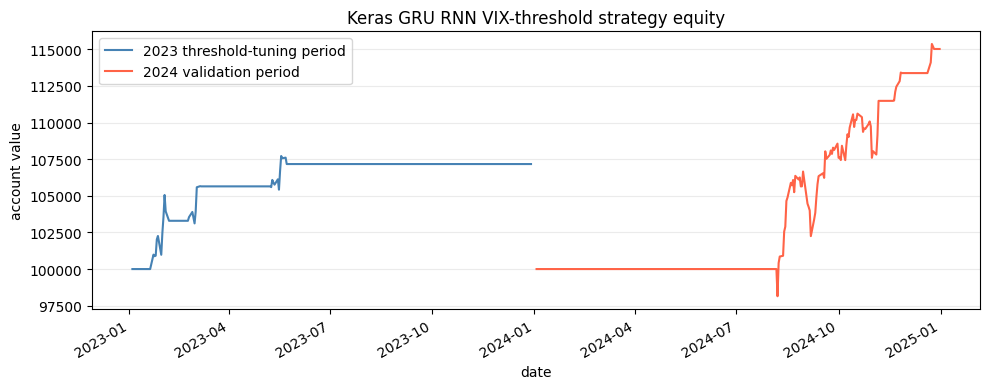

In [16]:
rnn_bt_test = Backtest(spx_test, VixPredStrategy, cash=100_000, commission=0, exclusive_orders=True)

rnn_opt, rnn_heatmap = rnn_bt_test.optimize(
    vix_rise_threshold=[0.005, 0.01, 0.02, 0.03, 0.04, 0.05],
    vix_fall_threshold=[-0.05, -0.04, -0.03, -0.02, -0.01, -0.005],
    maximize="Sharpe Ratio",
    constraint=lambda p: p.vix_fall_threshold < p.vix_rise_threshold,
    return_heatmap=True,
)

rnn_best_rise = rnn_opt._strategy.vix_rise_threshold
rnn_best_fall = rnn_opt._strategy.vix_fall_threshold

rnn_bt_val = Backtest(spx_val, VixPredStrategy, cash=100_000, commission=0, exclusive_orders=True)
rnn_val_results = rnn_bt_val.run(
    vix_rise_threshold=rnn_best_rise,
    vix_fall_threshold=rnn_best_fall,
)

backtest_metrics = ["Buy & Hold Return [%]", "Return [%]", "Max. Drawdown [%]", "Sharpe Ratio", "# Trades"]
print("Test results")
print(rnn_opt[backtest_metrics])
print("\nValidation results")
print(rnn_val_results[backtest_metrics])
print(f"\nBest thresholds from 2023: rise={rnn_best_rise}, fall={rnn_best_fall}")

plot_backtest_equity(rnn_opt, rnn_val_results, MODEL_LABEL)
rnn_bt_val.plot(plot_equity=False, plot_volume=False, plot_return=False);
